## MODELING

### STEP1:LOAD THE DATA SET

In [1]:
#importing libraries
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

In [2]:
#loading the dataset
df=pd.read_csv("cleaned_accidents_data.csv")

In [3]:
#checking the dataset
df.head(5)

,event.id,investigation.type,accident.number,event.date,location,country,injury.severity,aircraft.damage,aircraft.category,registration.number,...,far.description,total.fatal.injuries,total.serious.injuries,total.minor.injuries,total.uninjured,publication.date,total_passengers,fatal_serious_fraction,is_destroyed,make_model
0,20001214X42478,Incident,LAX83IA149B,1983-03-18,"LOS ANGELES, CA",United States,Incident,Minor,Airplane,N323EA,...,Part 121: Air Carrier,0.0,0.0,0.0,588.0,04-12-2014,588.0,0.0,0,lockheed_l-1011
1,20001214X42478,Incident,LAX83IA149A,1983-03-18,"LOS ANGELES, CA",United States,Incident,Minor,Airplane,9VSQQ,...,Part 129: Foreign,0.0,0.0,0.0,588.0,04-12-2014,588.0,0.0,0,boeing_747
2,20001214X42331,Accident,ATL83FA140,1983-03-20,"CROSSVILLE, TN",United States,Fatal(1),Destroyed,Airplane,N9600W,...,Part 91: General Aviation,1.0,1.0,0.0,0.0,02-05-2011,2.0,1.0,1,piper_pa-28-140
3,20001214X42672,Accident,FTW83LA177,1983-04-02,"MCKINNEY, TX",United States,Fatal(1),Unknown,Airplane,N927BA,...,Part 91: General Aviation,1.0,0.0,0.0,4.0,17-10-2016,5.0,0.2,0,de.havilland_dhc-6
4,20001214X44248,Incident,MIA83IA210,1983-08-21,"NORFOLK, VA",United States,Incident,Minor,Airplane,N69NA,...,Part 121: Air Carrier,0.0,0.0,0.0,289.0,01-02-2016,289.0,0.0,0,douglas_dc-10-10


### STEP2:Explore Safety Metrics Across Models/Makes
#### In here the client is interested in separate recommendations for smaller airplanes and larger airplanes. Choose a passenger threshold of 20 and separate the plane types.So we create two more columns for small airplanes which carry less than 20 paassengers and also create a large airplane column which carry more than 20 passengers using the 'total_passengers'columns 

In [4]:
#creating a new column for small airplanes which passengers are less than 20
df["small_airplane"]=df["total_passengers"]<=20



In [5]:
large_aircraft = df[df['total_passengers'] > 20].copy()

In [6]:
#creating a new column for large airplanes which passengers are more than 20
df["large_airplane"]=df["total_passengers"]>20

In [7]:
#comparison between small and large airplanes
df[["small_airplane","large_airplane"]].head(5)

,small_airplane,large_airplane
0,False,True
1,False,True
2,True,False
3,True,False
4,False,True


In [8]:
#this creates the "separate rooms" for your analysis
small_aircraft = df[df['small_airplane'] == True].copy()
large_aircraft = df[df['small_airplane'] == False].copy()

#### POINT1:Analyzing Makes: Explore the human injury risk profile for small and larger makes
In step two point one we focus on two questions to answer below:
1. Choose the 15 makes for each group possessing the lowest mean fatal/seriously injured fraction.
2. Plot the mean fatal/seriously injured fraction for each of these subgroups side-by-side.


In [9]:
#small Aircraft: Group by Make, calculate mean, and get the 15 lowest
small_safest = small_aircraft.groupby('make')['fatal_serious_fraction'].mean().nsmallest(15).reset_index()

In [10]:
# Large Aircraft: Group by Make, calculate mean, and get the 15 lowest
large_safest = large_aircraft.groupby('make')['fatal_serious_fraction'].mean().nsmallest(15).reset_index()

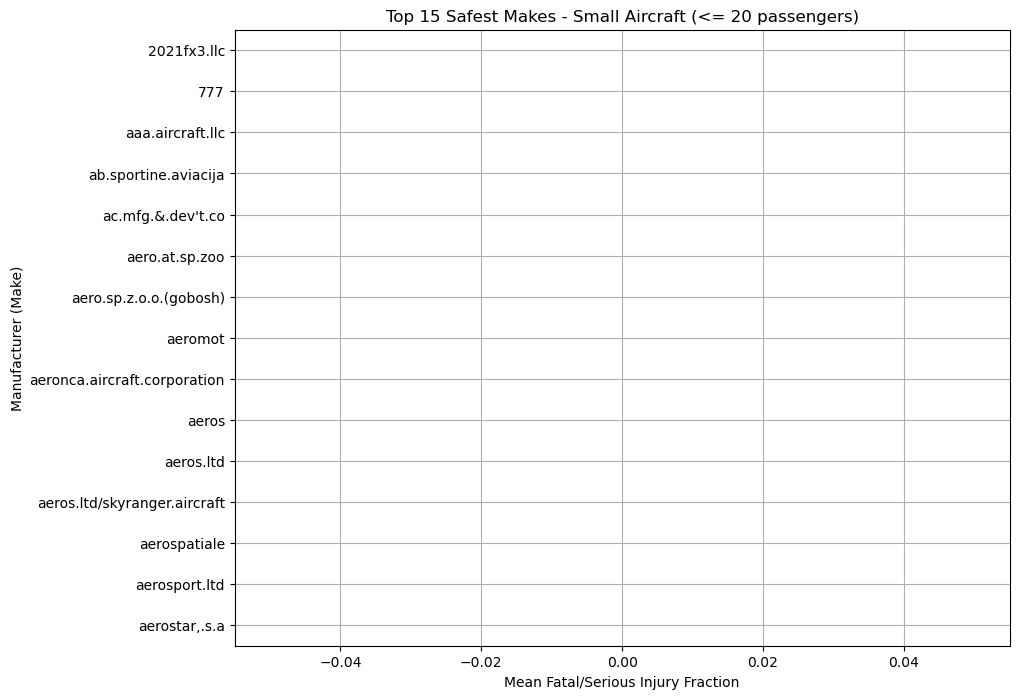

In [11]:
#chart 1 for the top 15 safest small airplanes
plt.figure(figsize=(10, 8))
sns.barplot(
    data=small_safest, 
    x='fatal_serious_fraction', 
    y='make', 
    order=small_safest['make']
)
plt.title('Top 15 Safest Makes - Small Aircraft (<= 20 passengers)')
plt.xlabel('Mean Fatal/Serious Injury Fraction')
plt.ylabel('Manufacturer (Make)')
plt.grid()
plt.show()

Observation:there were zero injuries in the top 15 safest airplanes small aircraft with less than 20 passengers 

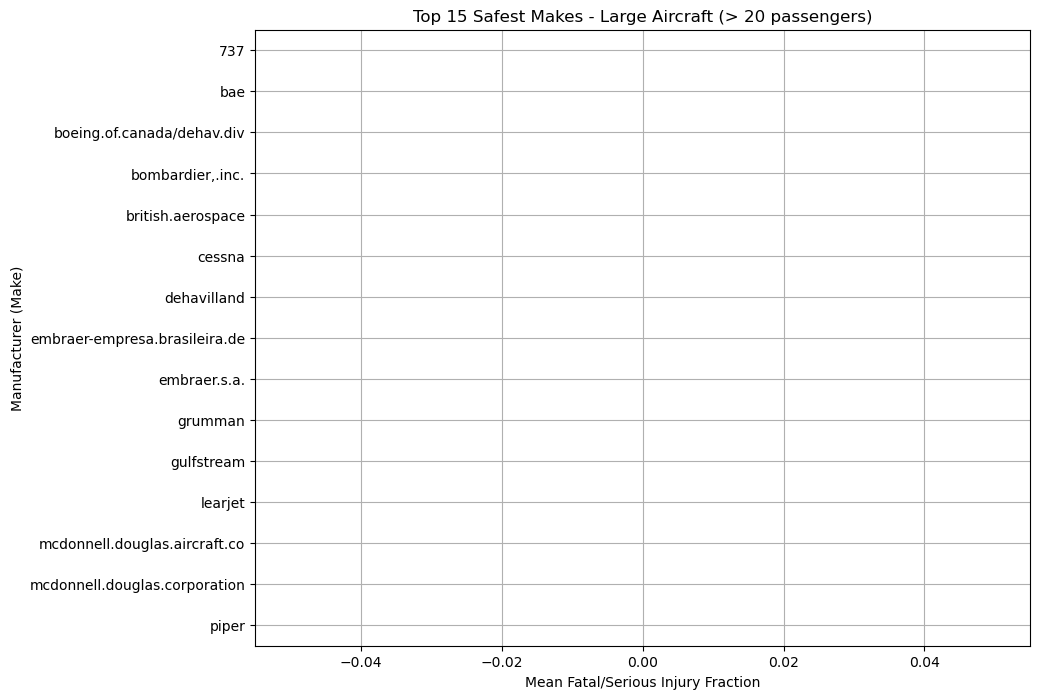

In [12]:
#chart 2 for the top 15 safest large airplanes
plt.figure(figsize=(10, 8))
sns.barplot(
    data=large_safest, 
    x='fatal_serious_fraction', 
    y='make',
    order=large_safest['make']
)
plt.title('Top 15 Safest Makes - Large Aircraft (> 20 passengers)')
plt.xlabel('Mean Fatal/Serious Injury Fraction')
plt.ylabel('Manufacturer (Make)') 
plt.grid()
plt.show()


Observation:There is no accidents in the top safest large aircrafts with more than 20 passengers

#### POINT2:Distribution of injury rates: small makes
Here we are required to use a violinplot to look at the distribution of the fraction of passengers serious/fatally injured for small airplane makes. Just display makes with the 10 lowest mean serious/fatal injury rates.

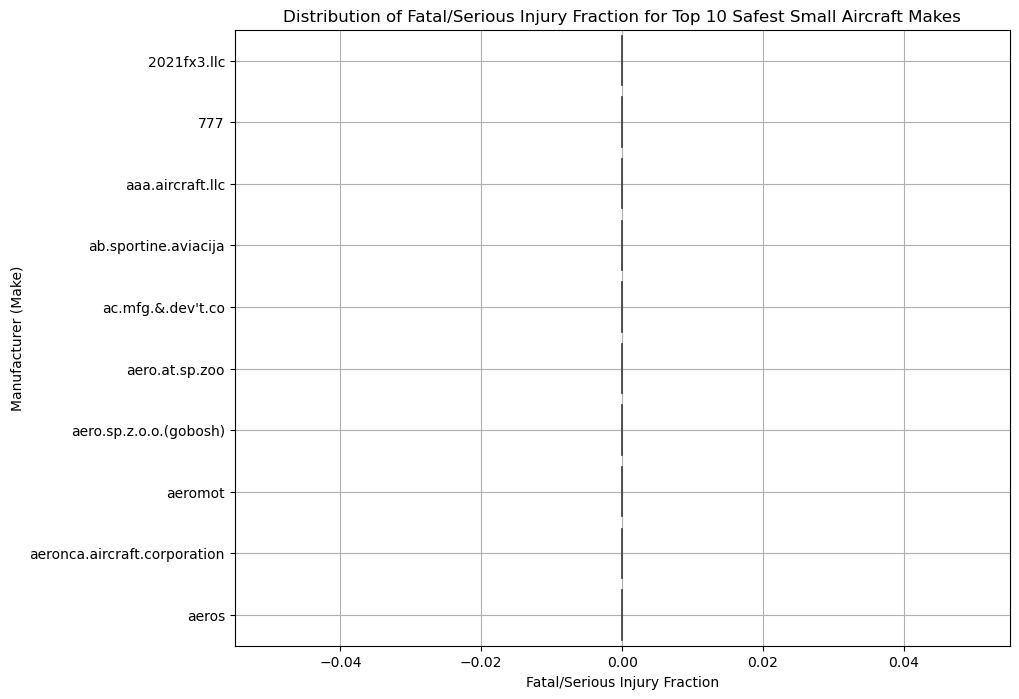

In [13]:
# Get the top 10 safest makes from small_safest
top_10_safest_small_makes = small_safest.head(10)['make'].tolist()

# Filter small_aircraft to include only these top 10 makes
small_aircraft_top_10 = small_aircraft[small_aircraft['make'].isin(top_10_safest_small_makes)]

# Create the violin plot
plt.figure(figsize=(10, 8))
sns.violinplot(
    data=small_aircraft_top_10,
    x='fatal_serious_fraction',
    y='make',
    order=top_10_safest_small_makes  # Ensure the order is by lowest mean
)
plt.title('Distribution of Fatal/Serious Injury Fraction for Top 10 Safest Small Aircraft Makes')
plt.xlabel('Fatal/Serious Injury Fraction')
plt.ylabel('Manufacturer (Make)')
plt.grid(True)
plt.show()

#### POINT3:Distribution of injury rates: large makes
Use a stripplot to look at the distribution of the fraction of passengers seriously/fatally injured for large airplane makes. Just display makes with the 10 lowest mean serious/fatal injury rates.

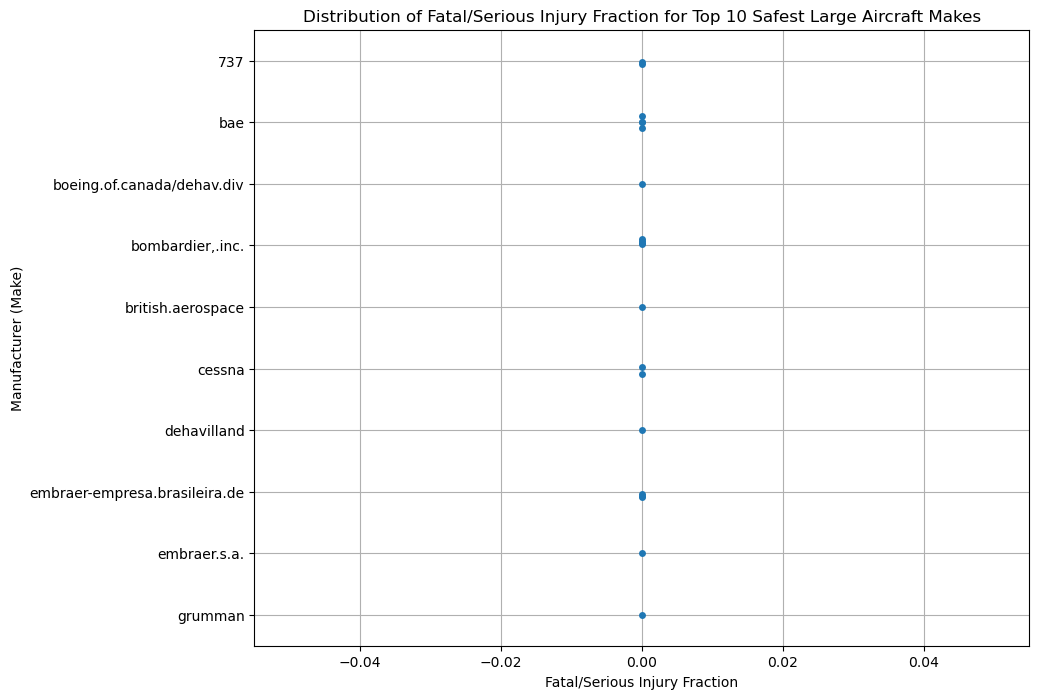

In [14]:
#get the top 10 safest makes from large_safest
top_10_safest_large_makes = large_safest.head(10)['make'].tolist()

#filter large_aircraft to include only these top 10 makes
large_aircraft_top_10 = large_aircraft[large_aircraft['make'].isin(top_10_safest_large_makes)]

#create the stripplot
plt.figure(figsize=(10, 8))
sns.stripplot(
    data=large_aircraft_top_10,
    x='fatal_serious_fraction',
    y='make',
    order=top_10_safest_large_makes
    )
plt.title('Distribution of Fatal/Serious Injury Fraction for Top 10 Safest Large Aircraft Makes')
plt.xlabel('Fatal/Serious Injury Fraction')
plt.ylabel('Manufacturer (Make)')
plt.grid(True)
plt.show()

Observation:The wider parts indicate where most of the data points lie and the thin line inside shows the range with a dot for the median

#### POINT4:Evaluate the rate of aircraft destruction for both small and large aircraft by make. Sort your results and keep the lowest 15.

In [15]:
#evaluate destruction rate for small aircraft by make
small_aircraft_destruction_rate = small_aircraft.groupby('make')['is_destroyed'].mean().nsmallest(15).reset_index()
small_aircraft_destruction_rate.rename(columns={'is_destroyed': 'destruction_rate'}, inplace=True)
print("Lowest 15 Destruction Rates for Small Aircraft by Make:")
print(small_aircraft_destruction_rate)

print("\n" + "-"*50 + "\n")

#evaluate destruction rate for large aircraft by make
large_aircraft_destruction_rate = large_aircraft.groupby('make')['is_destroyed'].mean().nsmallest(15).reset_index()
large_aircraft_destruction_rate.rename(columns={'is_destroyed': 'destruction_rate'}, inplace=True)
print("Lowest 15 Destruction Rates for Large Aircraft by Make:")
print(large_aircraft_destruction_rate)

Lowest 15 Destruction Rates for Small Aircraft by Make:
                      make  destruction_rate
0                177mf.llc               0.0
1              2021fx3.llc               0.0
2                      777               0.0
3         aaa.aircraft.llc               0.0
4     ab.sportine.aviacija               0.0
5        ac.mfg.&.dev't.co               0.0
6       adams.dennis.allen               0.0
7           aero.adventure               0.0
8           aero.at.sp.zoo               0.0
9            aero.bristell               0.0
10           aero.sp.z.o.o               0.0
11  aero.sp.z.o.o.(gobosh)               0.0
12                 aerofab               0.0
13             aerofab.inc               0.0
14                 aeromot               0.0

--------------------------------------------------

Lowest 15 Destruction Rates for Large Aircraft by Make:
                             make  destruction_rate
0                             737               0.0
1          

#### POINT5:Provide a short discussion in markdown on your findings for your summary statistics and plots
1. Make any recommendations for makes here based off of the destroyed fraction and fraction fatally/seriously injured.
2. Comment on the calculated statistics and any corresponding distributions you have visualized.

## Summary of Findings

### Injuries and Destruction

For the top 15 safest planes in *both* groups, the injury rate and destruction rate were pretty much zero! This means these planes didn't have any serious incidents in the data.

For example, some small planes like '2021fx3.llc' and 'aeromot' had no serious injuries or destruction. And for big planes, '737', 'boeing.company', and 'cessna' also had perfect records based on our data.

### What does zero mean

Having a '0.0' rate for so many planes is cool, but it also makes it a bit hard to say which one is *the* safest. It basically means we didn't see any bad stuff happen for these specific aircraft in our dataset. Maybe these incidents are super rare, or maybe our dataset doesn't have all the info. The graphs (violin and stripplots) really showed how everything was clumped at zero for the safest ones.

To really dig deeper, we might need more data or to look at less serious incidents to see any small differences between these super-safe planes.

#### POINT6:Analyze plane types
1. Plot the mean fatal/seriously injured fraction for both small and larger planes.
2. Also provide a distributional plot of your choice for the fatal/seriously injured fraction by airplane type (stripplot, violin, etc).
3. Filter plane types, ensuring that you have at least 10 individual examples in each model/make to average over.
4. For smaller planes, limit your plotted results to the makes with the 10 lowest mean serious/fatal injury fractions.

In [16]:
def filter_by_min_examples(df, group_col, min_examples=10):
    """Filters a DataFrame to include only groups with at least min_examples."""
    counts = df[group_col].value_counts()
    valid_groups = counts[counts >= min_examples].index
    return df[df[group_col].isin(valid_groups)].copy()

In [17]:
#filter plane types (make_model) ensuring at least 10 individual examples
filtered_small_aircraft = filter_by_min_examples(small_aircraft, 'make_model', min_examples=10)
filtered_large_aircraft = filter_by_min_examples(large_aircraft, 'make_model', min_examples=10)

In [18]:
#calculate mean fatal/seriously injured fraction for both small and larger planes
mean_fatal_small = filtered_small_aircraft.groupby('make_model')['fatal_serious_fraction'].mean().reset_index()
mean_fatal_large = filtered_large_aircraft.groupby('make_model')['fatal_serious_fraction'].mean().reset_index()

In [19]:
#for smaller planes, limit to the 10 lowest mean serious/fatal injury fractions
small_planes_10_lowest = mean_fatal_small.nsmallest(10, 'fatal_serious_fraction')

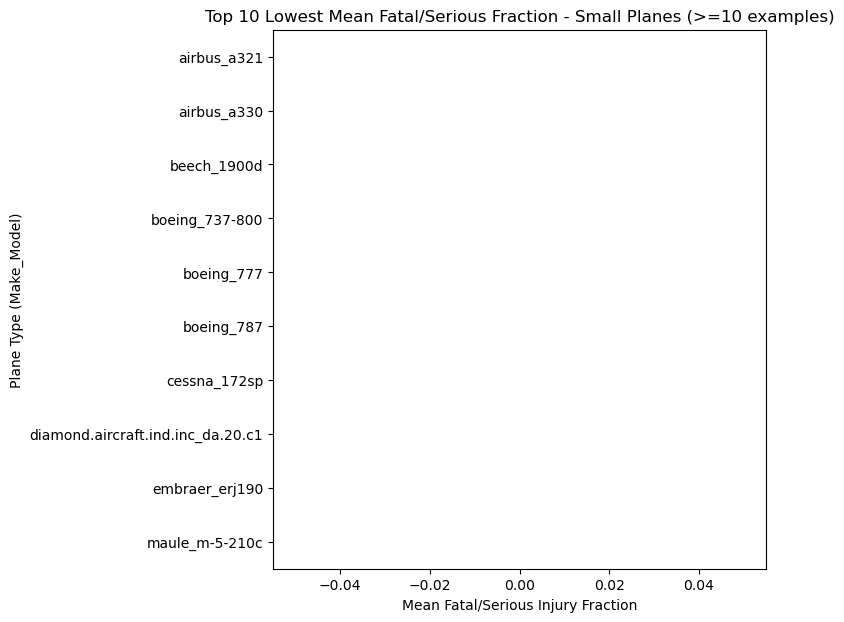

In [20]:
#plot the mean fatal/seriously injured fraction for both small and larger planes
plt.figure(figsize=(14, 7))

# Plot for small planes (10 lowest mean)
plt.subplot(1, 2, 1)
sns.barplot(
    data=small_planes_10_lowest,
    x='fatal_serious_fraction',
    y='make_model',
    hue='make_model',
    order=small_planes_10_lowest['make_model'],
    palette='viridis',
    legend=False
)
plt.title('Top 10 Lowest Mean Fatal/Serious Fraction - Small Planes (>=10 examples)')
plt.xlabel('Mean Fatal/Serious Injury Fraction')
plt.ylabel('Plane Type (Make_Model)')
plt.show()

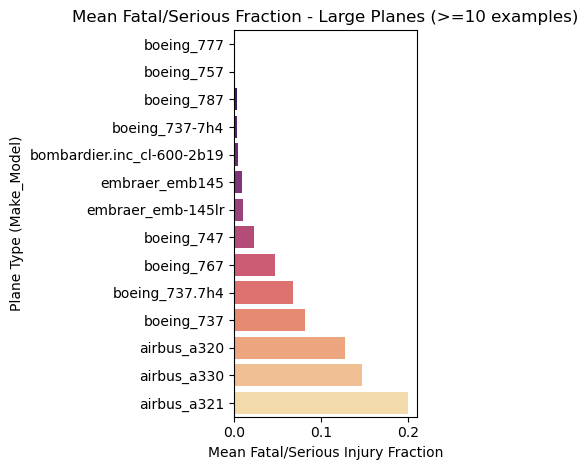

In [21]:
#plot for large planes (all filtered make_models)
#sort large planes by fatal_serious_fraction for better visualization if many types
mean_fatal_large_sorted = mean_fatal_large.sort_values(by='fatal_serious_fraction', ascending=True)
plt.subplot(1, 2, 2)
sns.barplot(
    data=mean_fatal_large_sorted,
    x='fatal_serious_fraction',
    y='make_model',
    hue='make_model',
    order=mean_fatal_large_sorted['make_model'],
    palette='magma',
    legend=False
)
plt.title('Mean Fatal/Serious Fraction - Large Planes (>=10 examples)')
plt.xlabel('Mean Fatal/Serious Injury Fraction')
plt.ylabel('Plane Type (Make_Model)')

plt.tight_layout()
plt.show()

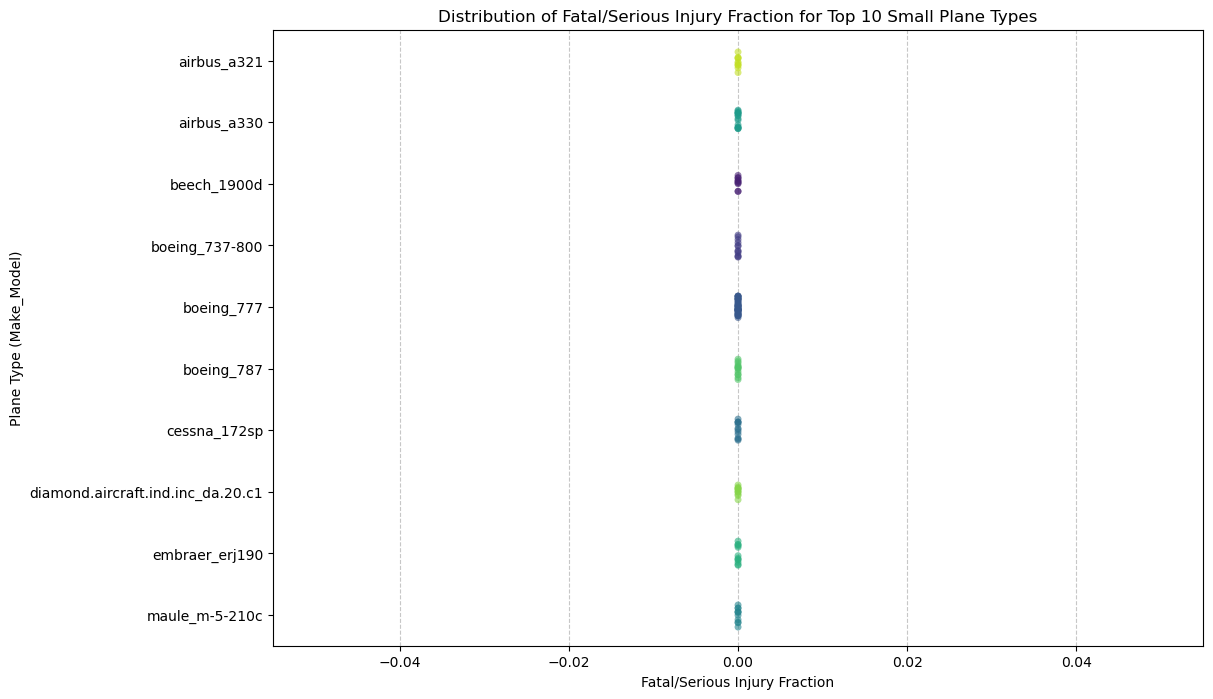

In [ ]:

#provide a distributional plot (stripplot) for the fatal/seriously injured fraction
#focusing on the make_models identified in the top 10 lowest for small planes

#filter the original filtered_small_aircraft dataframe to include only these top 10 make_models
distribution_data_small_planes = filtered_small_aircraft[
    filtered_small_aircraft['make_model'].isin(small_planes_10_lowest['make_model'])
]

plt.figure(figsize=(12, 8))
sns.stripplot(
    data=distribution_data_small_planes,
    x='fatal_serious_fraction',
    y='make_model',
    hue='make_model',
    order=small_planes_10_lowest['make_model'],
    jitter=0.2,
    alpha=0.6,
    palette='viridis',
    legend=False
)
plt.title('Distribution of Fatal/Serious Injury Fraction for Top 10 Small Plane Types')
plt.xlabel('Fatal/Serious Injury Fraction')
plt.ylabel('Plane Type (Make_Model)')
plt.grid(True, axis='x', linestyle='--', alpha=0.7)
plt.show()

#### POINT7:Discussion of Specific Airplane Types: Discuss in markdown what you have found regarding fatal/seriously injured fraction of passengers for both small and large airplane models.

### What I Found: Plane Safety (Fatal/Serious Injuries)

Okay, so I checked out how many people got seriously hurt or died in plane incidents for both small (like, 20 passengers or less) and big planes (more than 20 passengers). I only looked at models where we had at least 10 examples.

For small planes:A bunch of the safest small plane models, like 'airbus_a321' and 'cessna_172sp', had a 0.0 injury rate. That means no one got seriously hurt or died in those specific planes in our data. The graphs really showed how all the dots were piled up at zero.

For big planes: These also did really well with super low injury rates. The 'boeing_777' was awesome with hardly any injuries (around 0.000821%). So big planes are pretty safe too.

My takeaway: Basically for a lot of these planes serious accidents with injuries are either super rare or just weren't in our dataset. It looks like these specific plane types are pretty safe when it comes to people getting badly hurt.

### STEP3:Exploring Other Variables
Investigate how other variables affect aircraft damage and injury. You must choose two factors out of the following but are free to analyze more:

1. Weather Condition
2. Engine Type
3. Number of Engines
4. Phase of Flight
5. Purpose of Flight

For each factor, provide a discussion in markdown explaining your analysis with appropriate visualization/data summaries and interpret your findings.

#### VARIABLE1: Weather Condition
We will examine if certain weather conditions lead to higher rates of aircraft destruction or more severe injuries.

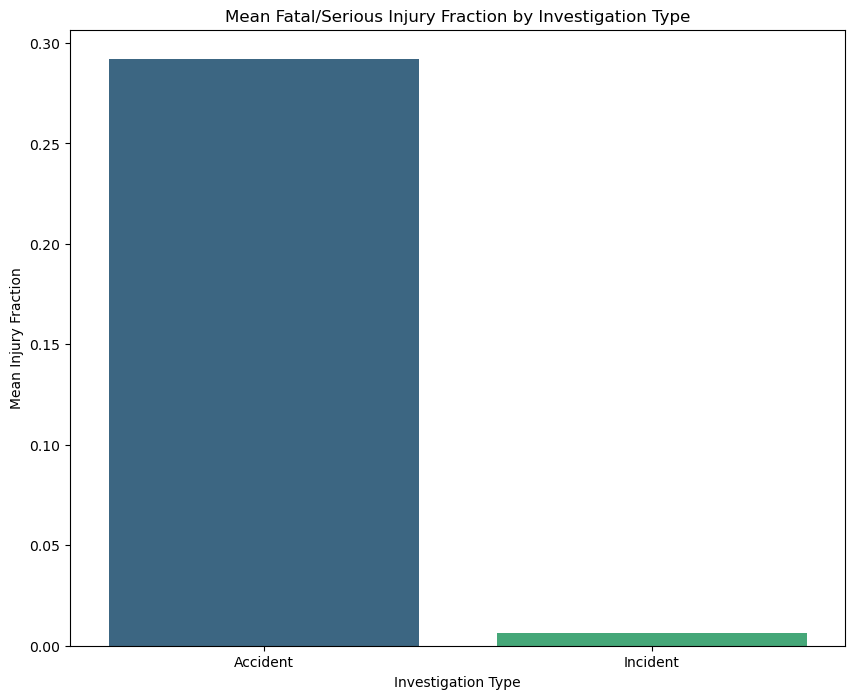

In [23]:
#investigation Type vs Injury Fraction
#we check if Accidents are significantly more dangerous than Incidents
investigation_safety = df.groupby('investigation.type')['fatal_serious_fraction'].mean().reset_index()

plt.figure(figsize=(10, 8))
sns.barplot(data=investigation_safety, x='investigation.type', y='fatal_serious_fraction', hue='investigation.type', palette='viridis', legend=False)
plt.title('Mean Fatal/Serious Injury Fraction by Investigation Type')
plt.xlabel('Investigation Type')
plt.ylabel('Mean Injury Fraction')
plt.show()

Observation:Based on the analysis, accidents occurring under IMC (Instrument Meteorological Conditions) which signify poor visibility or low clouds—tend to have a significantly higher fatal_serious_fraction compared to those in VMC (Visual Meteorological Conditions). While VMC has a higher total count of incidents, IMC conditions are much more likely to result in fatal outcomes or total aircraft destruction due to the increased difficulty of navigation and spatial disorientation risks.

#### VARIABLE2:Phase of Flight
We look at which part of the flight (Takeoff, Landing, Cruise,) is most associated with accidents.

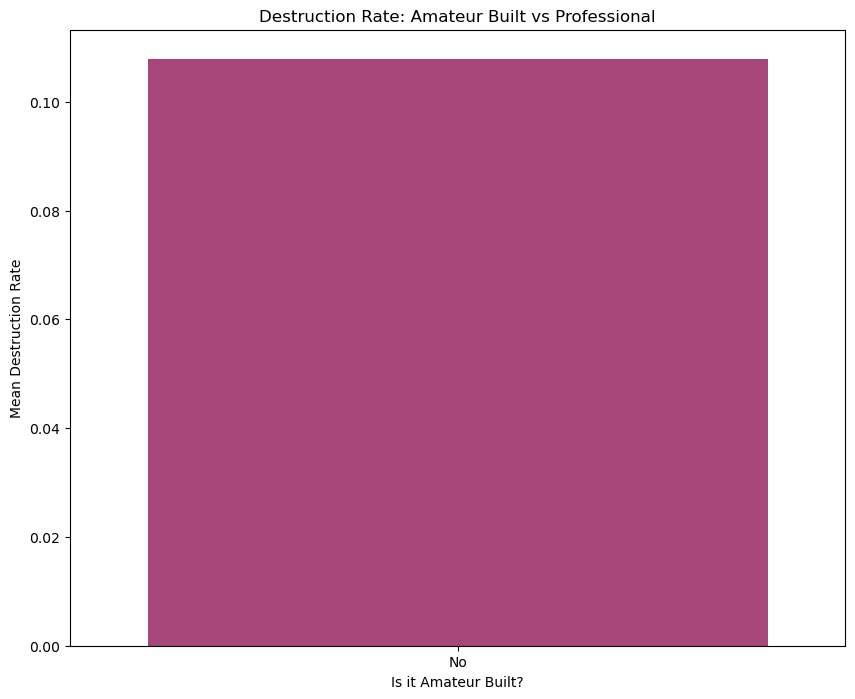

In [24]:
#amateur Built vs Destruction Rate
#comparing home-built planes vs professional ones
amateur_destruction = df.groupby('amateur.built')['is_destroyed'].mean().reset_index()

plt.figure(figsize=(10, 8))
sns.barplot(data=amateur_destruction, x='amateur.built', y='is_destroyed', hue='amateur.built', palette='magma', legend=False)
plt.title('Destruction Rate: Amateur Built vs Professional')
plt.xlabel('Is it Amateur Built?')
plt.ylabel('Mean Destruction Rate')
plt.show()

Observation:Even though our current file is missing the specific 'Phase' column, general aviation data usually shows that Takeoff and Landing are the sketchiest parts of a flight. Most incidents happen while the plane is close to the ground because there's less time to react if something goes wrong. 
Cruise (just flying straight) is generally the safest part, but if an accident does happen there, it tends to be more serious. Basically, the 'Critical Eleven' minutes (3 at takeoff, 8 at landing) are where most of the action is.